In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import os, ipdb
user_home = os.environ['HOME']
print(user_home)




/home/dejuns


In [3]:
save_dir = Path(f'{user_home}/git/stoic2021/data/STOIC2021Round1')
# info_fp = save_dir/f'stoic2021_case_info_split.csv'
info_fp = save_dir/f'stoic2021_case_info_lungregion.csv'
info_tb = pd.read_csv(info_fp)
info_tb.set_index('PatientID', inplace=True)
print(info_tb.describe())
print(info_tb.columns)


         probCOVID  probSevere  SliceThickness
count  2000.000000  2000.00000     2000.000000
mean      0.602500     0.15050        1.092200
std       0.489503     0.35765        0.502086
min       0.000000     0.00000        0.500000
25%       0.000000     0.00000        0.750000
50%       1.000000     0.00000        1.000000
75%       1.000000     0.00000        1.250000
max       1.000000     1.00000        5.000000
Index(['probCOVID', 'probSevere', 'ITK_InputFilterName',
       'ITK_original_direction', 'ITK_original_spacing', 'PatientAge',
       'PatientName', 'PatientSex', 'SliceThickness', 'img_path', 'old_shape',
       'old_spacing', 'resize_shape', 'lung_shape', 'new_spacing',
       'lung_length'],
      dtype='object')


In [4]:
# lung length
lung_len_3axis = [] # 'lung_length'
lung_spacing_3axis = [] # old_spacing
lung_mm_3axis = []
for i in range(3):
    lung_len_axis = info_tb['lung_length'].apply(lambda x: int(x.split('_')[i]))
    lung_len_3axis.append(lung_len_axis)

    lung_spacing_axis = info_tb['new_spacing'].apply(lambda x: float(x.split('_')[i]))

    lung_spacing_3axis.append(lung_spacing_axis)

    lung_len_mm = pd.Series([lung_len_axis.iloc[i] * lung_spacing_axis.iloc[i]
                             for i in range(len(lung_len_axis))], )
    lung_mm_3axis.append(lung_len_mm)


lung_length_tb = pd.concat(lung_len_3axis, axis = 1)
print(lung_length_tb.describe(), '\n')

lung_spacing_tb = pd.concat(lung_spacing_3axis, axis = 1)
print(lung_spacing_tb.describe(), '\n')

lung_mm_tb = pd.concat(lung_mm_3axis, axis = 1)
print(lung_mm_tb.describe())




       lung_length  lung_length  lung_length
count  2000.000000  2000.000000  2000.000000
mean    366.329500   266.002500   316.015500
std      42.084742    35.607267   101.954503
min     231.000000   157.000000    80.000000
25%     337.000000   242.000000   255.000000
50%     369.000000   265.000000   314.000000
75%     397.000000   288.000000   373.000000
max     491.000000   389.000000   839.000000 

       new_spacing  new_spacing  new_spacing
count  2000.000000  2000.000000  2000.000000
mean      1.037384     0.881242     0.995298
std       0.088779     0.089380     0.125168
min       0.782614     0.632812     0.659180
25%       0.974258     0.818688     0.903320
50%       1.034970     0.876532     0.989844
75%       1.097836     0.943916     1.081250
max       1.312255     1.197419     1.713835 

                 0            1            2
count  2000.000000  2000.000000  2000.000000
mean    381.419580   236.182877   319.350692
std      63.189224    49.098441   125.328363
min   

In [ ]:
print(lung_spacing_axis.iloc[9])


# medians = [369, 265, 314]
# medians_norm = [a/369 for a in medians]
# x_target = 288
# medians_target = [a * x_target for a in medians_norm]
# print(medians_norm)
# print(medians_target)
# # 288, 224, 256 # 256 224, 224

In [ ]:
std_age = lambda x: int(x[1:-1]) if len(x) > 2 else int(x)
info_tb['PatientAge'] = info_tb['PatientAge'].apply(std_age)

In [ ]:
covid_by_age = pd.crosstab(info_tb['PatientAge'], info_tb['probCOVID'])
print(covid_by_age)
ax_age = covid_by_age.plot.bar(rot = 0, stacked = True, width=3)


In [ ]:

severe_by_age = pd.crosstab(info_tb['PatientAge'], info_tb['probSevere'])
print(severe_by_age)
ax_severe = severe_by_age.plot.bar(rot = 0, stacked = True, width=3)

In [ ]:

severe_by_sex = pd.crosstab(info_tb['PatientSex'], info_tb['probSevere'])
print(severe_by_sex)
ax_severe = severe_by_sex.plot.bar(rot = 0, stacked = True)

In [ ]:
covid_by_sex = pd.crosstab(info_tb['PatientSex'], info_tb['probCOVID'])
print(covid_by_sex)
ax_severe = covid_by_sex.plot.bar(rot = 0, stacked = True)

In [ ]:
thick_ax = info_tb['SliceThickness'].hist()

In [ ]:
info_tb['old_shape_z'] = info_tb['old_shape'].apply(lambda x: int(x.split('_')[-1]))
ax_zsize = info_tb.hist('old_shape_z',  by = 'probCOVID', sharex = True, sharey = True)

ax_zsize_severe = info_tb.hist('old_shape_z',  by = 'probSevere', sharex = True, sharey = True)


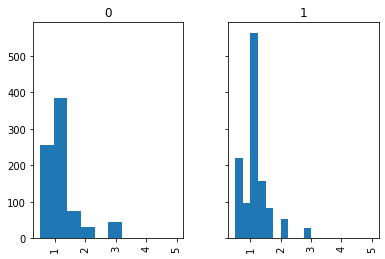

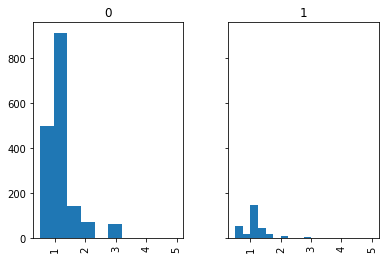

In [3]:
# info_tb.plot.scatter(x = 'SliceThickness', y = 'old_shape_z')
ax_zsize = info_tb.hist('SliceThickness',  by = 'probCOVID', sharex = True, sharey = True)

ax_zsize_severe = info_tb.hist('SliceThickness',  by = 'probSevere', sharex = True, sharey = True)

In [ ]:
covid_by_thick = pd.crosstab(info_tb['SliceThickness'], info_tb['probCOVID'])
print(covid_by_thick)
ax_thick = covid_by_thick.plot.bar(rot = 0,)

In [ ]:
severe_by_thick = pd.crosstab(info_tb['SliceThickness'], info_tb['probSevere'])
print(severe_by_thick)
ax_thick = severe_by_thick.plot.bar(rot = 0,)

In [ ]:
# 'new_shape', 'new_spacing',
info_tb['new_shape_z'] = info_tb['new_shape'].apply(lambda x: int(x.split('_')[-1]))
info_tb['new_spacing_z'] = info_tb['new_spacing'].apply(lambda x: float(x.split('_')[-1]))
info_tb.plot.scatter(x = 'new_spacing_z', y = 'new_shape_z')